# 08 — Explainability (SHAP)

Global drivers, local per-customer explanations, and importance-by-segment for the champion churn model from `05_churn_models.ipynb` — retrained on the full pre-test pool (all 5 quarterly snapshots) since model selection is already done; still explained only against the held-out test cutoff.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data import config
from churn.dataset import build_training_pool, build_snapshot, feature_columns, LABEL_COLUMN
from churn.train import train_xgboost
from explainability.shap_utils import (compute_shap_values, global_importance, top_drivers,
                                         local_explanation, importance_by_segment)

ROOT = '../data/raw'
customers = pd.read_parquet(f'{ROOT}/customers.parquet')
orders = pd.read_parquet(f'{ROOT}/orders.parquet')
interactions = pd.read_parquet(f'{ROOT}/interactions.parquet')
support = pd.read_parquet(f'{ROOT}/support.parquet')
products = pd.read_parquet(f'{ROOT}/products.parquet')

train_cutoffs = [pd.Timestamp(d) for d in
                 ['2024-09-30', '2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30']]
pool = build_training_pool(customers, orders, interactions, support, products, train_cutoffs)
test_cutoff = pd.Timestamp(config.OBSERVATION_CUTOFF)
test_pool = build_snapshot(customers, orders, interactions, support, products, test_cutoff)

feat_cols = feature_columns(pool)
X_train, y_train = pool[feat_cols], pool[LABEL_COLUMN]
X_test, y_test = test_pool[feat_cols], test_pool[LABEL_COLUMN]

model = train_xgboost(X_train, y_train)
shap_values, X_transformed, feature_names = compute_shap_values(model, X_test)
print('shap_values:', shap_values.shape)

shap_values: (5097, 39)


## Global feature importance (mean |SHAP|)

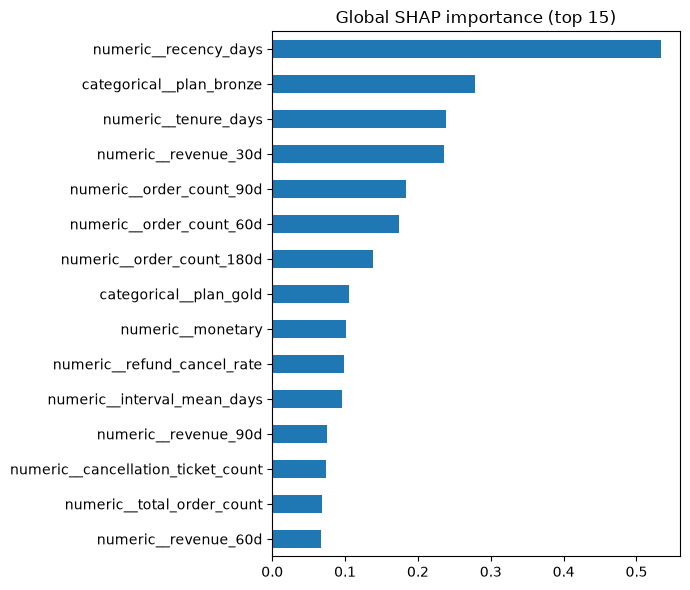

numeric__recency_days                 0.533058
categorical__plan_bronze              0.278886
numeric__tenure_days                  0.238591
numeric__revenue_30d                  0.235989
numeric__order_count_90d              0.183806
numeric__order_count_60d              0.173473
numeric__order_count_180d             0.138884
categorical__plan_gold                0.106066
numeric__monetary                     0.101552
numeric__refund_cancel_rate           0.098933
numeric__interval_mean_days           0.095731
numeric__revenue_90d                  0.075718
numeric__cancellation_ticket_count    0.073655
numeric__total_order_count            0.068910
numeric__revenue_60d                  0.066468
dtype: float32

In [2]:
importance = global_importance(shap_values, feature_names)
importance.head(15).sort_values().plot(kind='barh', figsize=(7, 6), title='Global SHAP importance (top 15)')
plt.tight_layout()
plt.show()
importance.head(15)

## Top drivers — direction, not just magnitude

`top_drivers` correlates each feature's own value with its own SHAP value — a plain mean-SHAP-across-customers would wash out to ~0 for a feature like recency that pushes churn risk up when high and down when low, even though it's clearly the most important feature (see `tests/unit/test_explainability.py` for the case that caught this).

In [3]:
increases_risk, decreases_risk = top_drivers(shap_values, X_transformed, feature_names, n=8)
print('higher value -> MORE churn risk:')
print(increases_risk.round(3))
print('\nhigher value -> LESS churn risk:')
print(decreases_risk.round(3))

higher value -> MORE churn risk:
numeric__recency_days                 0.971
categorical__plan_bronze              0.934
numeric__tenure_days                  0.470
numeric__interval_mean_days           0.505
numeric__cancellation_ticket_count    0.854
numeric__frequency                    0.315
numeric__category_breadth             0.457
categorical__country_AU               0.798
dtype: float64

higher value -> LESS churn risk:
categorical__plan_gold                      -0.926
categorical__country_GB                     -0.915
numeric__baseline_order_rate                -0.907
numeric__order_count_180d                   -0.901
categorical__acquisition_channel_referral   -0.871
numeric__order_count_30d                    -0.854
numeric__non_qualifying_count               -0.836
numeric__order_count_60d                    -0.831
dtype: float64


**Prediction vs. causation, concretely**: `country_AU` and `country_GB` show up with strong directional correlations above — but the synthetic generator (`src/data/generator.py`) never encodes a country effect on churn at all; country is assigned independently of the hazard process. This is exactly the guide's warning made visible: a real, computable SHAP correlation is not the same as a real causal driver — with 6 countries and ~1,000-2,700 customers apiece, some spurious correlation is statistically expected, and a naive read of this output would wrongly conclude "AU customers churn more." Compare with `recency_days` / `plan_bronze` / order-count features, which the generator DOES causally encode — those are the trustworthy drivers here.

## Local explanations: highest- and lowest-risk customers

In [4]:
proba = model.predict_proba(X_test)[:, 1]
highest_idx = proba.argmax()
lowest_idx = proba.argmin()

print(f"Highest risk: {test_pool.iloc[highest_idx]['customer_id']}, "
      f'predicted churn probability {proba[highest_idx]:.1%}')
display(local_explanation(shap_values, feature_names, highest_idx, X_transformed).head(8))

print(f"\nLowest risk: {test_pool.iloc[lowest_idx]['customer_id']}, "
      f'predicted churn probability {proba[lowest_idx]:.2%}')
display(local_explanation(shap_values, feature_names, lowest_idx, X_transformed).head(8))

Highest risk: C000726, predicted churn probability 99.4%


,feature_value,shap_value
numeric__recency_days,3.328558,1.969942
numeric__tenure_days,2.437571,0.436703
numeric__order_count_90d,-1.100542,0.386109
numeric__revenue_30d,-0.664497,0.355668
numeric__frequency,2.441164,0.324188
numeric__revenue_90d,-0.940706,0.279932
numeric__order_count_60d,-1.016547,0.229945
numeric__monetary,3.324356,0.195833



Lowest risk: C007297, predicted churn probability 0.08%


,feature_value,shap_value
numeric__monetary,10.247367,-1.058119
numeric__recency_days,-0.765561,-0.839761
numeric__revenue_90d,4.059171,-0.680803
numeric__order_count_180d,4.649429,-0.568070
numeric__interval_mean_days,-0.873014,-0.495014
numeric__order_count_90d,4.598508,-0.457784
categorical__plan_gold,1.000000,-0.416833
categorical__plan_bronze,0.000000,-0.372771


The highest-risk customer's top driver is an extreme `recency_days` z-score (3.3 std above average — a customer who hasn't ordered in a very long time) plus low recent order/revenue counts. The lowest-risk customer shows the mirror image: high monetary value, low (recent) recency, and high order counts across every window — a textbook loyal, active customer. Both explanations are directionally exactly what a domain expert would expect, which is the sanity check that matters most before trusting SHAP output on a real business.

## Feature importance by segment (plan)

In [5]:
importance_by_segment(shap_values, feature_names, test_pool['plan'], top_n=6).round(3)

,numeric__recency_days,categorical__plan_bronze,numeric__tenure_days,numeric__revenue_30d,numeric__order_count_90d,numeric__order_count_60d
segment,,,,,,
bronze,0.448,0.296,0.264,0.163,0.145,0.130
gold,0.699,0.322,0.196,0.358,0.265,0.256
silver,0.533,0.240,0.236,0.246,0.181,0.175


`recency_days` matters most for `gold` customers (0.70) — when a normally-frequent gold customer goes quiet, that's a strong, unusual signal. It matters least for `bronze` (0.45), where infrequent activity is closer to the norm, so a gap in ordering says comparatively less. Full write-up in `docs/explainability_report.md`.